#***Rainfall_Prediction_Project***

In [66]:
# Importing main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
# For machine learning
from sklearn.model_selection import train_test_split

In [68]:
# Loading dataset
df = pd.read_csv('/content/weatherAUS.csv.zip')

In [69]:
# first 5 rows
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [70]:
# Checking dataset shape (rows, columns)
print(df.shape)

(145460, 23)


In [71]:
# See column names
print(df.columns)

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')


# EDA (Exploratory Data Analysis)

In [72]:
# Basic info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [73]:
# Check for missing values
print(df.isnull().sum())

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


In [74]:
df.Location.value_counts()

,count
Location,
Canberra,3436
Sydney,3344
Adelaide,3193
Darwin,3193
Hobart,3193
Perth,3193
Melbourne,3193
Brisbane,3193
Albury,3040


# Preprocessing

In [75]:
# 1. Drop rows where we don't have the answer (RainTomorrow)
df.dropna(subset=['RainTomorrow'], inplace=True)

# 2. Extract Year, Month, Day from Date and then drop the Date column
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.drop('Date', axis=1, inplace=True)

# 3. Fill missing values for the rest of the columns
# Numerical: Fill with median | Categorical: Fill with most frequent
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 4. Final check - This should print 0
print("Total missing values now:", df.isnull().sum().sum())

Total missing values now: 0


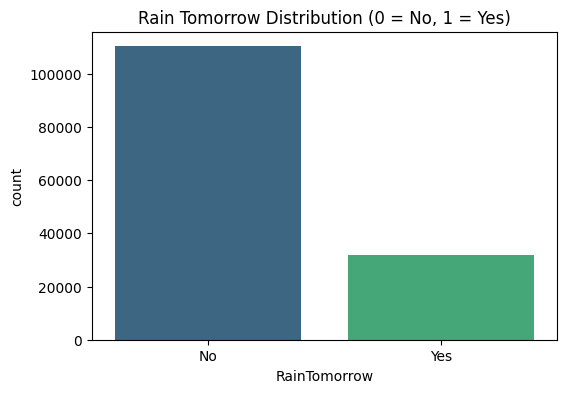

In [76]:
# Show the distribution of the target
plt.figure(figsize=(6,4))
sns.countplot(x='RainTomorrow', data=df, hue='RainTomorrow', palette='viridis', legend=False)
plt.title('Rain Tomorrow Distribution (0 = No, 1 = Yes)')
plt.show()

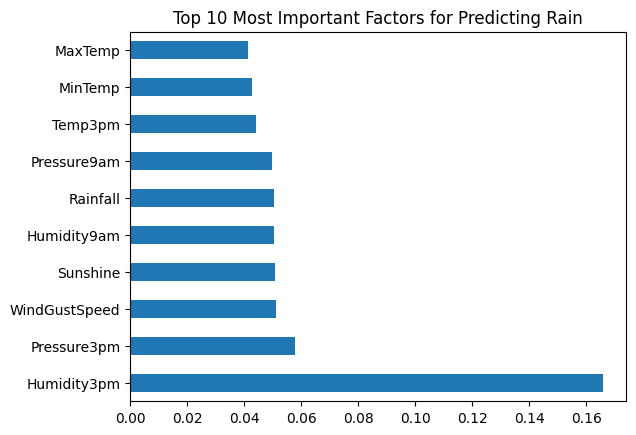

In [78]:
# Get feature importances from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Most Important Factors for Predicting Rain')
plt.show()

# Encoding & Splitting

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create an instance of LabelEncoder
le = LabelEncoder()

# Get all categorical (text) columns
categorical = [col for col in df.columns if df[col].dtype == 'object']

# Convert each text column into numbers
for col in categorical:
    df[col] = le.fit_transform(df[col])

# Look at the data now - it should be all numbers!
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,2,13.4,22.9,0.6,4.8,8.5,13,44.0,13,14,...,1007.1,8.0,5.0,16.9,21.8,0,0,2008,12,1
1,2,7.4,25.1,0.0,4.8,8.5,14,44.0,6,15,...,1007.8,5.0,5.0,17.2,24.3,0,0,2008,12,2
2,2,12.9,25.7,0.0,4.8,8.5,15,46.0,13,15,...,1008.7,5.0,2.0,21.0,23.2,0,0,2008,12,3
3,2,9.2,28.0,0.0,4.8,8.5,4,24.0,9,0,...,1012.8,5.0,5.0,18.1,26.5,0,0,2008,12,4
4,2,17.5,32.3,1.0,4.8,8.5,13,41.0,1,7,...,1006.0,7.0,8.0,17.8,29.7,0,0,2008,12,5


In [ ]:
from sklearn.preprocessing import StandardScaler

# X = Everything except the answer (RainTomorrow)
X = df.drop(['RainTomorrow'], axis=1)

# y = Only the answer
y = df['RainTomorrow']

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (113754, 24)
Testing set size: (28439, 24)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split # Ensure train_test_split is imported

# Split into Training (80%) and Testing (20%) - This line is duplicated from HzB8v0Ez1sOk to make this cell runnable independently
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

# We "fit" on the training data and "transform" both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the models
lr_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Logistic Regression model
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 3. Train the Random Forest model
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 4. Evaluate the results
print("--- Logistic Regression Accuracy ---")
print(accuracy_score(y_test, lr_preds))

print("\n--- Random Forest Accuracy ---")
print(accuracy_score(y_test, rf_preds))

--- Logistic Regression Accuracy ---
0.8396568093111572

--- Random Forest Accuracy ---
0.8541791202222301


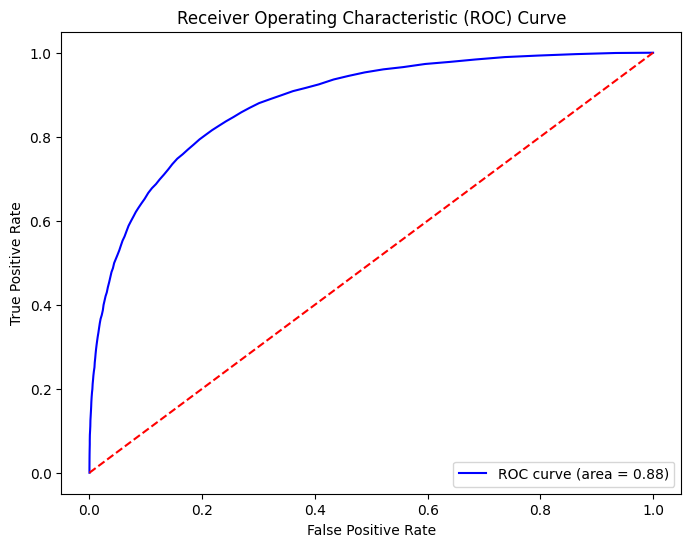

In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve, auc

# Get probabilities from Random Forest
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Evaluation

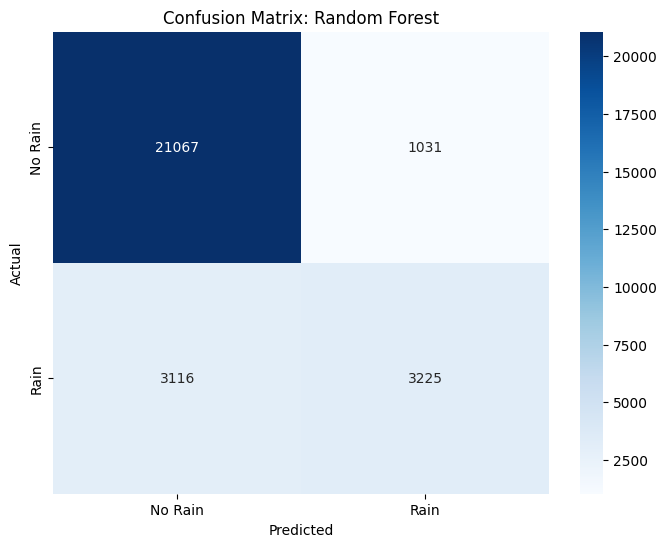

In [ ]:
# Create a heatmap for the Random Forest results
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.show()

# Prediction & Validation

In [ ]:
X = df.drop(['RainTomorrow'], axis=1)

def predict_rain(input_data):
    # Convert input to a DataFrame and scale it
    input_df = pd.DataFrame([input_data], columns=X.columns)
    scaled_input = scaler.transform(input_df)

    # Predict
    prediction = rf_model.predict(scaled_input)

    if prediction[0] == 1:
        return "Yes, it will likely rain tomorrow!"
    else:
        return "No, it will likely be clear tomorrow"

# --- EXAMPLE TEST ---
# Let's create a test case with high humidity (often leads to rain)
test_case = X.iloc[0].copy() # Get a sample row structure
test_case['Humidity3pm'] = 90.0
test_case['Pressure3pm'] = 1005.0

print(predict_rain(test_case))

Yes, it will likely rain tomorrow!


In [ ]:
# 5-Fold Cross Validation
from sklearn.model_selection import cross_val_score

# This checks the model 5 times on different data slices
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print(f"Average Cross-Validation Accuracy: {cv_scores.mean()*100:.2f}%")

Average Cross-Validation Accuracy: 84.20%
